In [4]:
#=========================================================================================================================================================
# (Phase 2, Week 1)
# PROJECT: Refinery Big Data Processing 
# MODULE: Industrial Dataset Generator & Storage Engine
# APPLICATION: Simulating Distillating SCADA Logs 
#=========================================================================================================================================================
import pandas as pd
import numpy as np
print("=================================================================================================================================================")
print('STARTING INDUSTRIAL DATA GENERATION ENGINE...')
# Generating  an automated timeline array of 1000 continuous minutes 
time_index =pd.date_range(start = '2026-06-19 04:00',periods=1000,freq='min')
# Synthesizing  physical process data with realistic random noise 
np.random.seed(42) # Ensures thr random noise values are reproducible 
temp_noise=np.random.normal(loc=180.0,scale=2.5,size=1000) # Mean=180'c
flow_noise=np.random.normal(loc=25.0,scale=0.8,size=1000) # Mean=25 m3/h
press_noise=np.random.normal(loc=101.3,scale=1.2,size=1000) # Mean=101.3kPa
# Assembling the raw individual data arrays into a Pandas DataFrame grid
raw_data={'Timestamp':time_index, 'Internal_Temperature_C':temp_noise,'Feed_Flow_m3h':flow_noise,'Column_Pressure_kPa':press_noise}
df=pd.DataFrame(raw_data)
# Introducing artificial sensor dropouts (NaN gaps) to simulate instrumental failures
df.iloc[15:20,1]=np.nan # Temperature sensor goes off for 5 minutes
df.iloc[450:458,2]=np.nan # Flow meter drops out for 8 minutes
# Exporting the entire DataFrame structure out to a permanent CSV flie 
output_filename='Refinery_Sensor_Logs.csv'
df.to_csv(output_filename,index=False)
print(f'\n{"\033[32m"}[SUCESS]: Generated {len(df)} rows of operational log data.{"\033[0m"}')
print(f"Data saved permanently to workspace file:'{output_filename}'")
# Loading the generated CSV data back into memory
df=pd.read_csv('Refinery_Sensor_Logs.csv')
# Print the top 5 rows to verify the columns loaded cleanly 
print(f'\n{"\033[4;50m"}FIRST 5 ROWS OF RAW REFINERY LOGS{"\033[0m"}')
print(df.head())
# Print a summary of the missing data points across all sensors 
print(f'\n{"\033[0m"}COUNT OF MISSING VALUES (NaN) PER SENSOR{"\033[0m"}')
print(df.isnull().sum())
#=======================================================================================================================================================
# PART B
# PROJECT: Refinery Big Processing
# MODULE: Data Cleansing & Vectorized Transformation
# APPLICATION: Repairing SCADA Sensor Blackouts 
print('====================================================================================================================================================')
print(f'\n{"\033[32m"}STARTING VECTORIZED CLEANING PIPELINE...{"\033[0m"}')
# Repairing the Internal Temperature Column using Forward-Fill. Note that .dropna() can also be used 
df['Internal_Temperature_C']=df['Internal_Temperature_C'].ffill()
df_cleaned=df.dropna()
print(f'\n{"\033[4;50m"}POST CLEANING SENSOR REPORT{"\033[0m"}')
print(df_cleaned.isnull().sum())
print(f'Original Row Count: {len(df)}|| Cleaned Row Count: {len(df_cleaned)}')
# INDUSTRIAL VECTORIZATION:
# Converting Temperature from Celsius to Farenheit 
df_cleaned['Internal_Temperature_F']=(df_cleaned['Internal_Temperature_C']*9/5)+32
print(f'\n{"\033[4;50m"}COMPLETED TRANSFORMATION DATA{"\033[0m"}')
print(df_cleaned[['Timestamp','Internal_Temperature_C','Internal_Temperature_F']].head())

print("=================================================================================================================================================")










STARTING INDUSTRIAL DATA GENERATION ENGINE...

[SUCESS]: Generated 1000 rows of operational log data.
Data saved permanently to workspace file:'Refinery_Sensor_Logs.csv'

FIRST 5 ROWS OF RAW REFINERY LOGS
             Timestamp  Internal_Temperature_C  Feed_Flow_m3h  \
0  2026-06-19 04:00:00              181.241785      26.119484   
1  2026-06-19 04:01:00              179.654339      25.739707   
2  2026-06-19 04:02:00              181.619221      25.047704   
3  2026-06-19 04:03:00              183.807575      24.482451   
4  2026-06-19 04:04:00              179.414617      25.558579   

   Column_Pressure_kPa  
0           100.489786  
1           101.126578  
2           100.349096  
3           100.930446  
4            99.027662  

COUNT OF MISSING VALUES (NaN) PER SENSOR
Timestamp                 0
Internal_Temperature_C    5
Feed_Flow_m3h             8
Column_Pressure_kPa       0
dtype: int64

STARTING VECTORIZED CLEANING PIPELINE...

POST CLEANING SENSOR REPORT
Timestamp       

C:\Users\user\AppData\Local\Temp\ipykernel_12104\652697667.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Internal_Temperature_F']=(df_cleaned['Internal_Temperature_C']*9/5)+32


[LOG]: Ingesting cleaned historical SCADA logs...
[SUCESS]: Process Visualization engine compiled flawlessly. Rendering Dashbord now.


<function matplotlib.pyplot.show(close=None, block=None)>

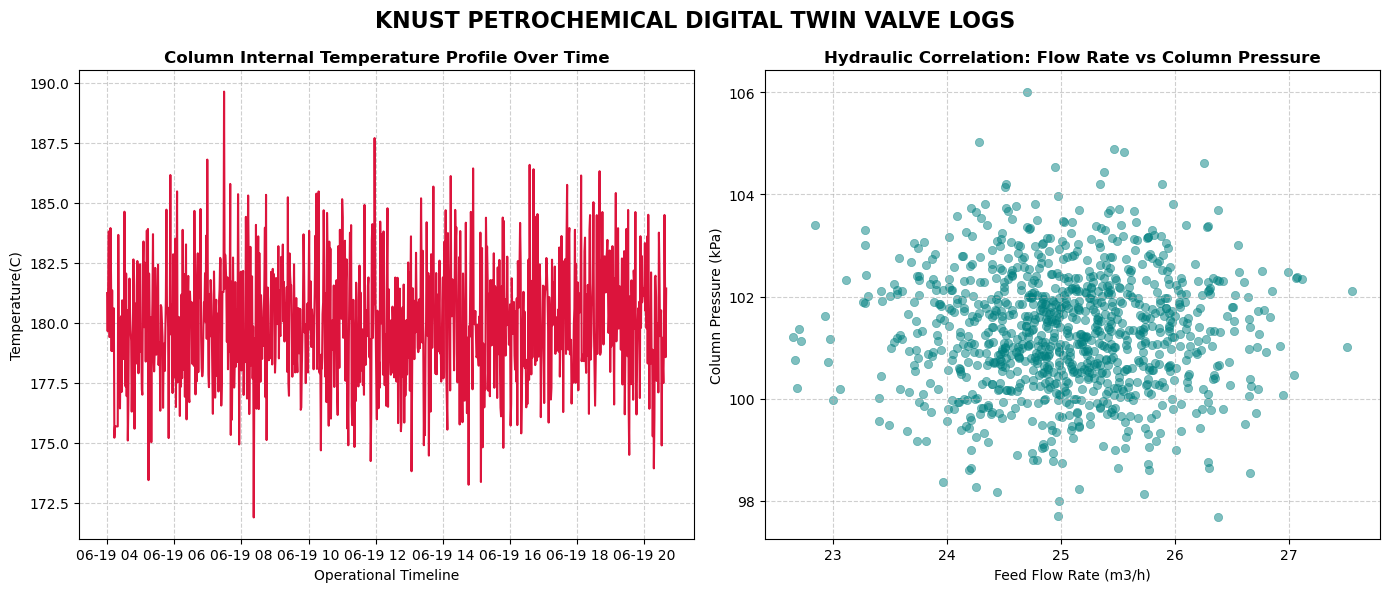

In [12]:
#=========================================================================================================================================================
# PROJECT: Refinery Big Data Visualization (Phase 2, Week 2)
# MODULE: Multi Plot Engineering Dashboard
# APPLICATION: Visual Process Diagnostics (SCADA Analytics)
#=========================================================================================================================================================
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
print(f"{"\033[2;36m"}[LOG]: Ingesting cleaned historical SCADA logs...{"\033[0m"}")
dF=df.dropna()
df["Timestamp"]=pd.to_datetime(df["Timestamp"])
fig,ax=plt.subplots(1,2,figsize=(14,6))
fig.suptitle("KNUST PETROCHEMICAL DIGITAL TWIN VALVE LOGS",fontsize=16,fontweight='bold')
# PLOT 1: TIME-SERIES THERMAL PROFILE 
sns.lineplot(data=df,x='Timestamp',y='Internal_Temperature_C',ax=ax[0],color='crimson',linewidth=1.5)
ax[0].set_title('Column Internal Temperature Profile Over Time',fontsize=12,fontweight='bold')
ax[0].set_xlabel('Operational Timeline',fontsize=10)
ax[0].set_ylabel('Temperature(C)',fontsize=10)
ax[0].grid(True,linestyle='--',alpha=0.6)
# PLOT 2: HYDRAULIC SYSTEM CORRELATION
sns.scatterplot(data=df,x='Feed_Flow_m3h',y='Column_Pressure_kPa',ax=ax[1],color='teal',alpha=0.5,edgecolor=None)
ax[1].set_title('Hydraulic Correlation: Flow Rate vs Column Pressure',fontsize=12,fontweight='bold')
ax[1].set_xlabel('Feed Flow Rate (m3/h)',fontsize=10)
ax[1].set_ylabel('Column Pressure (kPa)',fontsize=10)
ax[1].grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
print(f'{"\033[32m"}[SUCESS]: Process Visualization engine compiled flawlessly. Rendering Dashbord now.{"\033[0m"}')
plt.show